In [10]:
# Uvoz knjižnic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nastavitve za lepše grafe
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")

print("Knjižnice uvožene")

Knjižnice uvožene


In [11]:
# Uvoz podatkov
bdp = pd.read_csv('bdp.csv', sep=None, engine='python')
brezposelnost = pd.read_csv('brezposelnost.csv', sep=None, engine='python')
euribor = pd.read_csv('euribor.csv', sep=None, engine='python')
nepremicnine = pd.read_csv('nepremicnine.csv', sep=None, engine='python')

# Izgled podatkov
print("=== BDP ===")
print(bdp.head())
print("\n=== BREZPOSELNOST ===")
print(brezposelnost.head())
print("\n=== EURIBOR ===")
print(euribor.head())
print("\n=== NEPREMIČNINE ===")
print(nepremicnine.head())

=== BDP ===
  ﻿Cetrtletje  VrednostMio
0      2008Q1       8599.2
1      2008Q2       9789.7
2      2008Q3       9804.8
3      2008Q4       9548.3
4      2009Q1       8350.1

=== BREZPOSELNOST ===
  Cetrtletje  Brezposelnost%
0     2008Q1             5.1
1     2008Q2             4.2
2     2008Q3             4.1
3     2008Q4             4.3
4     2009Q1             5.4

=== EURIBOR ===
  Cetrtletje  Euribor3M
0     2008Q1   4.480003
1     2008Q2   4.860468
2     2008Q3   4.981791
3     2008Q4   4.214669
4     2009Q1   2.011676

=== NEPREMIČNINE ===
  Cetrtletje  Indeks
0     2008Q1  129.32
1     2008Q2  129.08
2     2008Q3  131.52
3     2008Q4  127.31
4     2009Q1  119.37


In [12]:
# Enotno poimenovanje stolpcev in ureditev vrednosti
bdp.columns = ['Cetrtletje', 'BDP']
brezposelnost.columns = ['Cetrtletje', 'Brezposelnost']
euribor.columns = ['Cetrtletje', 'Euribor']
nepremicnine.columns = ['Cetrtletje', 'Nepremicnine']

# Manjkajoča 1. vrstica pri nepremičninah
print("Nepremičnine - vse vrstice na začetku:")
print(nepremicnine.head(10))
print("\nStevilko vrstic v vsaki tabeli:")
print(f"BDP: {len(bdp)} vrstic")
print(f"Brezposelnost: {len(brezposelnost)} vrstic")
print(f"Euribor: {len(euribor)} vrstic")
print(f"Nepremičnine: {len(nepremicnine)} vrstic")

Nepremičnine - vse vrstice na začetku:
  Cetrtletje  Nepremicnine
0     2008Q1        129.32
1     2008Q2        129.08
2     2008Q3        131.52
3     2008Q4        127.31
4     2009Q1        119.37
5     2009Q2        116.93
6     2009Q3        114.95
7     2009Q4        116.97
8     2010Q1        117.41
9     2010Q2        118.08

Stevilko vrstic v vsaki tabeli:
BDP: 72 vrstic
Brezposelnost: 72 vrstic
Euribor: 72 vrstic
Nepremičnine: 72 vrstic


In [13]:
# Združitev vseh tabel v eno po stolpcu 'Cetrtletje'
df = bdp.merge(brezposelnost, on='Cetrtletje')
df = df.merge(euribor, on='Cetrtletje')
df = df.merge(nepremicnine, on='Cetrtletje')

# Številčni indeks za grafe (1, 2, 3, ... 72)
df['Indeks'] = range(len(df))

print("Združena tabela - prvih 5 vrstic:")
print(df.head())
print(f"\nOblikovanje tabele: {df.shape[0]} vrstic, {df.shape[1]} stolpcev")
print("\nAli manjkajo kakšni podatki?")
print(df.isnull().sum())

Združena tabela - prvih 5 vrstic:
  Cetrtletje     BDP  Brezposelnost   Euribor  Nepremicnine  Indeks
0     2008Q1  8599.2            5.1  4.480003        129.32       0
1     2008Q2  9789.7            4.2  4.860468        129.08       1
2     2008Q3  9804.8            4.1  4.981791        131.52       2
3     2008Q4  9548.3            4.3  4.214669        127.31       3
4     2009Q1  8350.1            5.4  2.011676        119.37       4

Oblikovanje tabele: 72 vrstic, 6 stolpcev

Ali manjkajo kakšni podatki?
Cetrtletje       0
BDP              0
Brezposelnost    0
Euribor          0
Nepremicnine     0
Indeks           0
dtype: int64


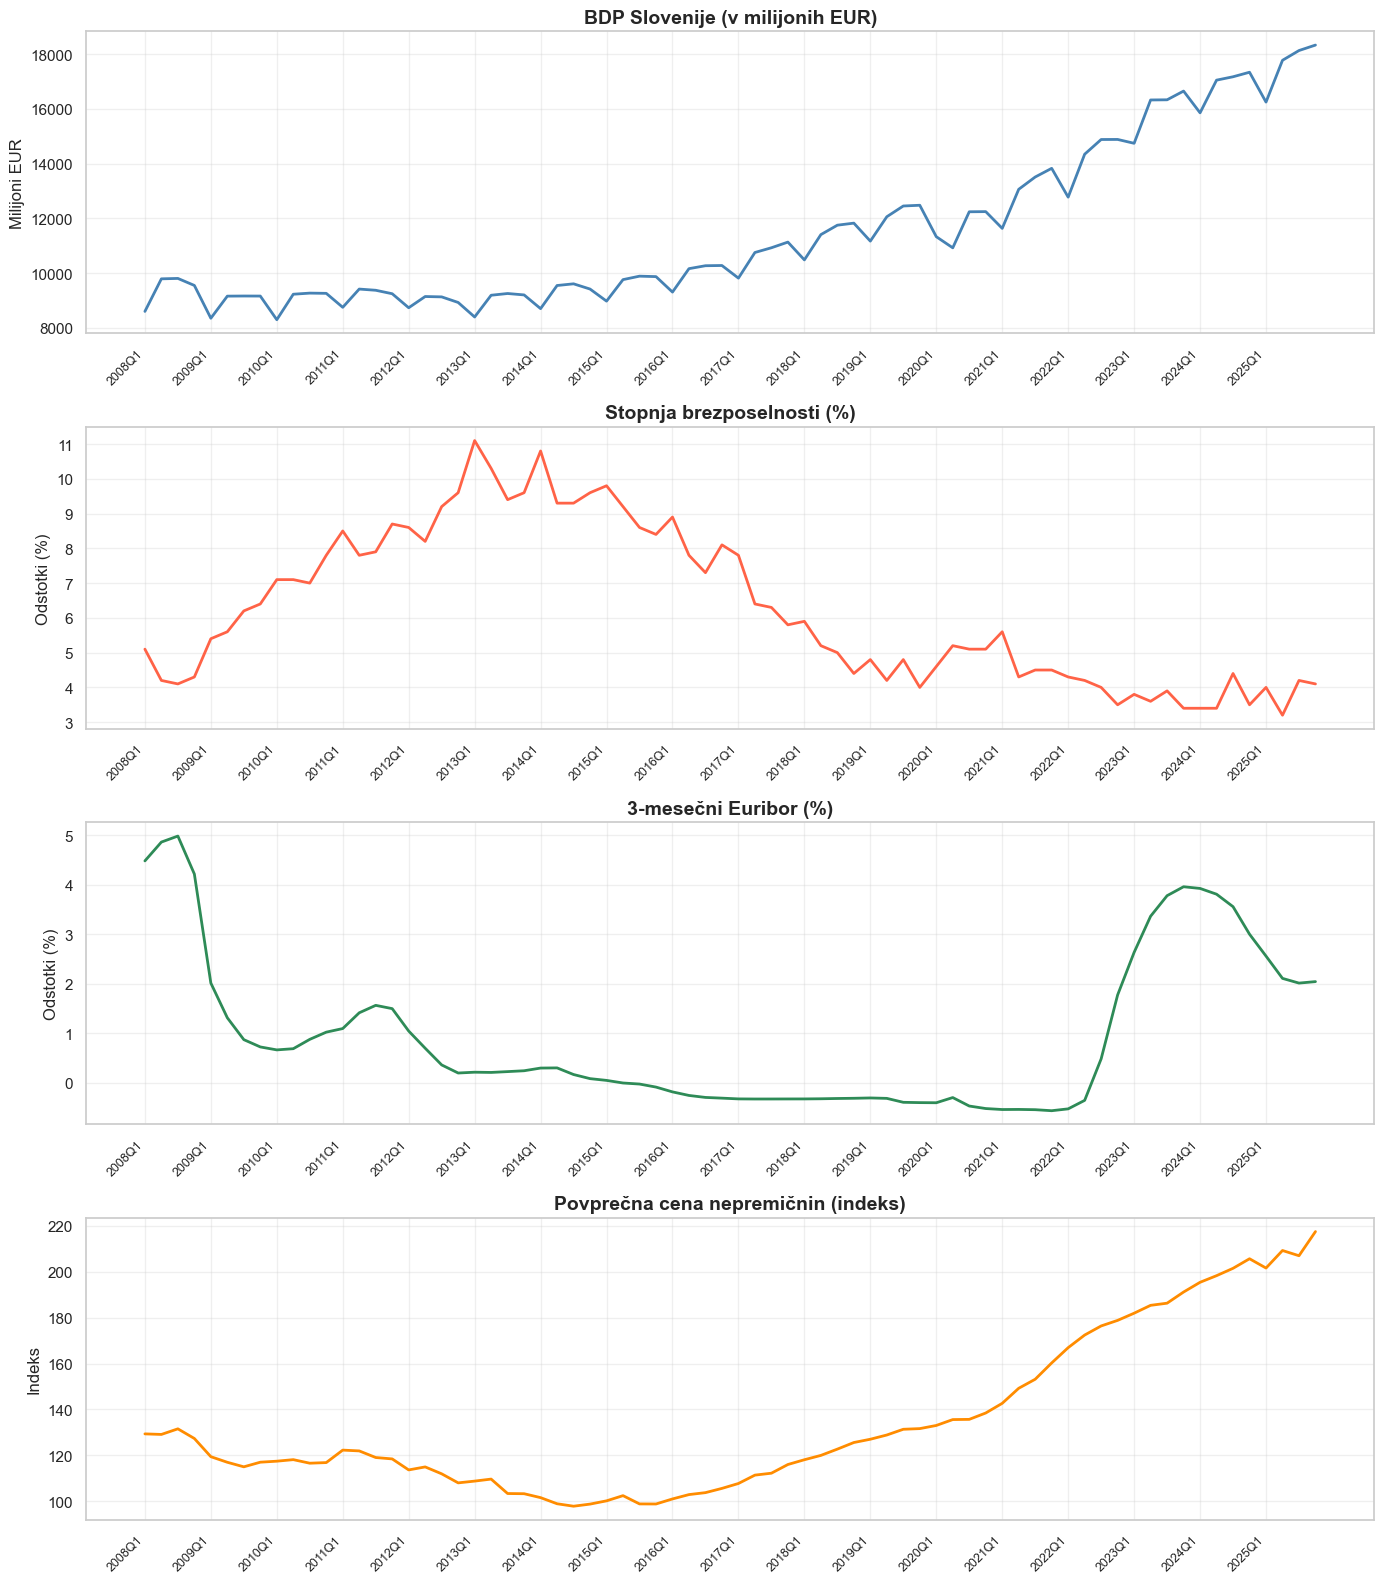

Grafi shranjeni


In [14]:
# Izris grafov za vse 4 spremenljivke
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# Graf 1: BDP
axes[0].plot(df['Indeks'], df['BDP'], color='steelblue', linewidth=2)
axes[0].set_title('BDP Slovenije (v milijonih EUR)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Milijoni EUR')

# Graf 2: Brezposelnost
axes[1].plot(df['Indeks'], df['Brezposelnost'], color='tomato', linewidth=2)
axes[1].set_title('Stopnja brezposelnosti (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Odstotki (%)')

# Graf 3: Euribor
axes[2].plot(df['Indeks'], df['Euribor'], color='seagreen', linewidth=2)
axes[2].set_title('3-mesečni Euribor (%)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Odstotki (%)')

# Graf 4: Nepremičnine
axes[3].plot(df['Indeks'], df['Nepremicnine'], color='darkorange', linewidth=2)
axes[3].set_title('Povprečna cena nepremičnin (indeks)', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Indeks')

# Oznake na x-osi (vsako 4. četrtletje = vsako leto)
leta = df['Cetrtletje'][::4].values
pozicije = df['Indeks'][::4].values
for ax in axes:
    ax.set_xticks(pozicije)
    ax.set_xticklabels(leta, rotation=45, ha='right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grafi_casovne_vrste.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafi shranjeni")

In [15]:
interpretacija = """
INTERPRETACIJA GRAFOV - 1.1
============================

1. BDP SLOVENIJE:
   - Dolgoročni trend rasti, z dvema opaznejšima padcema:
     * 2008-2009: Svetovna finančna kriza
     * 2020: Pandemija COVID-19
   - Sezonskost: BDP je vsako leto višji v Q2/Q3 (poletje) kot Q1/Q4
   - Po vsaki krizi sledi okrevanje in nadaljevanje rasti

2. BREZPOSELNOST:
   - Obratno sorazmerna z BDP (ko BDP raste, brezposelnost pada)
   - Vrh ~11% v 2013 (zakasnjen učinek finančne krize)
   - Trend padanja od 2013 do danes (izjema: kratki skok ob COVID-19)

3. EURIBOR:
   - Dramatičen padec po 2008 (ECB zniževala obrestne mere)
   - Zgodovinsko nizke / negativne obrestne mere 2015-2022
   - Hiter dvig 2022-2023 zaradi visoke inflacije v Evropi
   - Sedaj v fazi ponovnega zniževanja

4. CENE NEPREMIČNIN:
   - Padec 2008-2015 (finančna kriza + varčevanje)
   - Močna rast od 2015 naprej (nizke obrestne mere = poceni krediti)
   - Cene so se od 2015 do 2025 več kot podvojile
   - Ni jasnega sezonskega vzorca

VZORCI V PODATKIH:
- Trend: BDP in nepremičnine imajo pozitiven dolgoročni trend
- Sezonskost: BDP kaže sezonske vzorce (višji v poletnih četrtletjih)
- Cikličnost: vse spremenljivke reagirajo na gospodarske krize
"""

print(interpretacija)


INTERPRETACIJA GRAFOV - 1.1

1. BDP SLOVENIJE:
   - Dolgoročni trend rasti, z dvema opaznejšima padcema:
     * 2008-2009: Svetovna finančna kriza
     * 2020: Pandemija COVID-19
   - Sezonskost: BDP je vsako leto višji v Q2/Q3 (poletje) kot Q1/Q4
   - Po vsaki krizi sledi okrevanje in nadaljevanje rasti

2. BREZPOSELNOST:
   - Obratno sorazmerna z BDP (ko BDP raste, brezposelnost pada)
   - Vrh ~11% v 2013 (zakasnjen učinek finančne krize)
   - Trend padanja od 2013 do danes (izjema: kratki skok ob COVID-19)

3. EURIBOR:
   - Dramatičen padec po 2008 (ECB zniževala obrestne mere)
   - Zgodovinsko nizke / negativne obrestne mere 2015-2022
   - Hiter dvig 2022-2023 zaradi visoke inflacije v Evropi
   - Sedaj v fazi ponovnega zniževanja

4. CENE NEPREMIČNIN:
   - Padec 2008-2015 (finančna kriza + varčevanje)
   - Močna rast od 2015 naprej (nizke obrestne mere = poceni krediti)
   - Cene so se od 2015 do 2025 več kot podvojile
   - Ni jasnega sezonskega vzorca

VZORCI V PODATKIH:
- Trend

Korelacijska matrika:
                BDP  Brezposelnost  Euribor  Nepremicnine
BDP            1.00          -0.75     0.36          0.95
Brezposelnost -0.75           1.00    -0.41         -0.77
Euribor        0.36          -0.41     1.00          0.52
Nepremicnine   0.95          -0.77     0.52          1.00


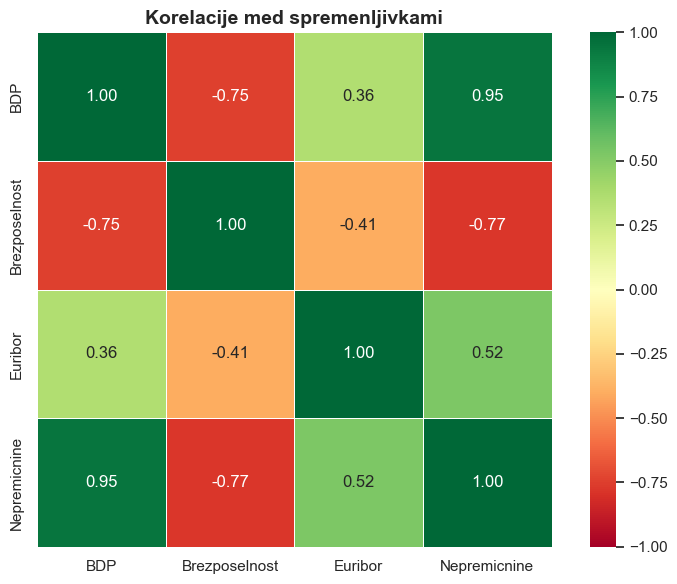

Korelacijska matrika shranjena


In [16]:
# Izračuna korelacije med vsemi spremenljivkami
korelacije = df[['BDP', 'Brezposelnost', 'Euribor', 'Nepremicnine']].corr()

print("Korelacijska matrika:")
print(korelacije.round(2))

# Heatmap (barvna tabela korelacij)
plt.figure(figsize=(8, 6))
sns.heatmap(korelacije, 
            annot=True,        # Pokaži številke
            fmt='.2f',         # 2 decimalki
            cmap='RdYlGn',     # Rdeča-rumena-zelena barvna lestvica
            vmin=-1, vmax=1,   # Lestvica: od -1 do 1
            square=True,
            linewidths=0.5)
plt.title('Korelacije med spremenljivkami', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('korelacije.png', dpi=150, bbox_inches='tight')
plt.show()
print("Korelacijska matrika shranjena")

In [17]:
razlaga_korelacij = """
ODNOSI MED SPREMENLJIVKAMI - 1.1
==================================

1. BDP in NEPREMIČNINE (0.95) - zelo močna pozitivna korelacija:
   - Gospodarska rast spodbuja povpraševanje po nepremičninah
   - Višji dohodki = več nakupov nepremičnin
   - Najpomembnejša povezava v podatkih

2. BDP in BREZPOSELNOST (-0.75) - močna negativna korelacija:
   - Klasična ekonomska zakonitost (Okunov zakon)
   - Gospodarska rast ustvarja delovna mesta

3. NEPREMIČNINE in BREZPOSELNOST (-0.77) - močna negativna korelacija:
   - Visoka brezposelnost zmanjša povpraševanje po nepremičninah
   - Brezposelni ne morejo pridobiti hipotekarnih kreditov

4. EURIBOR in NEPREMIČNINE (0.52) - zmerna pozitivna korelacija:
   - Presenetljivo pozitivna - pričakovali bi negativno
   - Razlog: oba visoka v 2008, oba nizka 2015-2021, oba spet rasla po 2022
   - Dolgoročno višji Euribor = dražji krediti = manj povpraševanja po nepremičninah

OPOMBA: Korelacija ne pomeni vzročnosti! Spremenljivke so lahko
povezane zaradi skupnih zunanjih dejavnikov (npr. gospodarski cikel).
"""

print(razlaga_korelacij)


ODNOSI MED SPREMENLJIVKAMI - 1.1

1. BDP in NEPREMIČNINE (0.95) - zelo močna pozitivna korelacija:
   - Gospodarska rast spodbuja povpraševanje po nepremičninah
   - Višji dohodki = več nakupov nepremičnin
   - Najpomembnejša povezava v podatkih

2. BDP in BREZPOSELNOST (-0.75) - močna negativna korelacija:
   - Klasična ekonomska zakonitost (Okunov zakon)
   - Gospodarska rast ustvarja delovna mesta

3. NEPREMIČNINE in BREZPOSELNOST (-0.77) - močna negativna korelacija:
   - Visoka brezposelnost zmanjša povpraševanje po nepremičninah
   - Brezposelni ne morejo pridobiti hipotekarnih kreditov

4. EURIBOR in NEPREMIČNINE (0.52) - zmerna pozitivna korelacija:
   - Presenetljivo pozitivna - pričakovali bi negativno
   - Razlog: oba visoka v 2008, oba nizka 2015-2021, oba spet rasla po 2022
   - Dolgoročno višji Euribor = dražji krediti = manj povpraševanja po nepremičninah

OPOMBA: Korelacija ne pomeni vzročnosti! Spremenljivke so lahko
povezane zaradi skupnih zunanjih dejavnikov (npr. g

In [18]:
odgovori_1_2 = """
ODGOVORI NA VPRAŠANJA - 1.2 ARIMAX MODEL
==========================================

VPRAŠANJE 1: Kakšne časovne vrste so primerne za ARIMAX?
----------------------------------------------------------
ARIMAX model zahteva STACIONARNE časovne vrste.
Stacionarna časovna vrsta ima:
- Konstantno povprečje skozi čas (brez trenda)
- Konstantno varianco (brez vse večjih nihanj)
- Ni sezonskosti

Naši podatki (BDP, nepremičnine) NISO stacionarni - imajo trend rasti.
Zato jih moramo pred modeliranjem 'stacionarizirati' z diferenciranjem
(od vsake vrednosti odštejemo prejšnjo vrednost).

TESTI PRED MODELIRANJEM:
- ADF test (Augmented Dickey-Fuller): preverimo ali je vrsta stacionarna
- KPSS test: dodatna potrditev stacionarnosti
- ACF/PACF grafi: pomagajo določiti parametre modela (p, q)
- Test sezonskosti: preverimo ali obstajajo sezonski vzorci

TESTI PO MODELIRANJU:
- Ljung-Box test: preverimo ali so ostanki (napake modela) naključni
- Shapiro-Wilk test: preverimo ali so ostanki normalno porazdeljeni
- Test heteroskedastičnosti: preverimo ali je varianca ostankov konstantna

VPRAŠANJE 2: Kaj mora veljati za eksogene spremenljivke?
---------------------------------------------------------
Eksogene spremenljivke morajo biti:
1. Stacionarne (ali jih stacionariziramo)
2. Dostopne v trenutku napovedi - problem: BDP za naslednje četrtletje
   še ne poznamo ko delamo napoved! Rešitev: uporabimo napoved BDP
   ali zamaknjene vrednosti (vrednosti iz prejšnjega četrtletja)
3. Neodvisne med seboj (ni multikolinearnosti)
4. Vzročno povezane z odvisno spremenljivko (ne samo korelirane)

VPRAŠANJE 3: Katera eksogena spremenljivka bi najbolj vplivala?
---------------------------------------------------------------
Po našem mnenju: BDP
Razlogi:
- Najvišja korelacija z nepremičninami (0.95)
- Ekonomsko logična povezava (gospodarska rast → višje cene)
- BDP zajema splošno gospodarsko stanje

Na drugem mestu: Brezposelnost (-0.77)
- Visoka brezposelnost zmanjša povpraševanje po nepremičninah
- Vpliva na sposobnost pridobitve hipotekarnega kredita

Euribor (0.52) je sicer pomemben, vendar njegova korelacija z
nepremičninami ni tako enoznačna kot pri BDP.

VPRAŠANJE 4: Kako oceniti napovedno moč modela?
------------------------------------------------
- Podatke razdelimo na učno množico (npr. 2008-2022) in testno (2023-2025)
- Model naučimo na učni množici, napovedi naredimo za testno
- Merimo napako napovedi z:
  * MAE (povprečna absolutna napaka)
  * RMSE (koren povprečne kvadratne napake)
  * MAPE (povprečna odstotna napaka)
- Pričakovana napoved: zmerna natančnost, ker cene nepremičnin
  so odvisne tudi od dejavnikov ki jih nimamo v modelu

VPRAŠANJE 5: Kako določiti parametre modela?
--------------------------------------------
Parametri ARIMAX modela so (p, d, q)(P, D, Q):
- p: število avtoregesivnih členov → določimo z PACF grafom
- d: stopnja diferenciranja → določimo z ADF testom
- q: število členov drsečega povprečja → določimo z ACF grafom
- Sezonski parametri (P,D,Q) → določimo z analizo sezonskosti

Praktično: uporabimo funkcijo auto_arima() ki samodejno poišče
najboljše parametre z minimizacijo kriterija AIC/BIC.

VPRAŠANJE 6: Kako bi napoved še izboljšali?
-------------------------------------------
Možne izboljšave:
1. Dodatni podatki:
   - Število izdanih gradbenih dovoljenj (ponudba nepremičnin)
   - Populacijski trendi in migracije
   - Povprečne plače (kupna moč)
   - Število odobrenih hipotek

2. Alternativni modeli:
   - VAR (Vector Autoregression): modelira vse spremenljivke skupaj
   - LSTM nevronska mreža: boljša pri kompleksnih nelinearnih vzorcih
   - XGBoost z zamaknjenimi spremenljivkami: dobro za tabelarične podatke

3. Tehnične izboljšave:
   - Daljše časovno obdobje (več podatkov = boljši model)
   - Mesečni namesto četrtletnih podatkov (več podatkovnih točk)
"""

print(odgovori_1_2)


ODGOVORI NA VPRAŠANJA - 1.2 ARIMAX MODEL

VPRAŠANJE 1: Kakšne časovne vrste so primerne za ARIMAX?
----------------------------------------------------------
ARIMAX model zahteva STACIONARNE časovne vrste.
Stacionarna časovna vrsta ima:
- Konstantno povprečje skozi čas (brez trenda)
- Konstantno varianco (brez vse večjih nihanj)
- Ni sezonskosti

Naši podatki (BDP, nepremičnine) NISO stacionarni - imajo trend rasti.
Zato jih moramo pred modeliranjem 'stacionarizirati' z diferenciranjem
(od vsake vrednosti odštejemo prejšnjo vrednost).

TESTI PRED MODELIRANJEM:
- ADF test (Augmented Dickey-Fuller): preverimo ali je vrsta stacionarna
- KPSS test: dodatna potrditev stacionarnosti
- ACF/PACF grafi: pomagajo določiti parametre modela (p, q)
- Test sezonskosti: preverimo ali obstajajo sezonski vzorci

TESTI PO MODELIRANJU:
- Ljung-Box test: preverimo ali so ostanki (napake modela) naključni
- Shapiro-Wilk test: preverimo ali so ostanki normalno porazdeljeni
- Test heteroskedastičnosti: prev